# 4. Co-occurrence matrices and simple embeddings

This notebook reads `observations.csv` and builds token co-occurrence matrices for window sizes 2, 4, and 6. Each row of a matrix is a vector representation of a token. PCA is then used to project the vectors into two dimensions, where each token is drawn as an arrow from the origin.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

INPUT_FILE = "../01-observations/observations.csv"
WINDOW_SIZES = [2, 4, 6]
SPECIAL_TOKENS = {"<s>", "</s>"}


In [2]:
df = pd.read_csv(INPUT_FILE)
print(f"Read {len(df)} observations.")
df.head()


Read 850 observations.


,id,sentence
0,1,s f e
1,2,s l l f e
2,3,s f e
3,4,s r r f e
4,5,s f e


## Build the vocabulary

The vocabulary contains the actual symbols of the fictional language. Sentence-boundary markers are excluded.

In [3]:
def tokenize(sentence):
    return sentence.split()

token_sequences = [tokenize(sentence) for sentence in df["sentence"]]
vocabulary = sorted({
    token for sequence in token_sequences for token in sequence
    if token not in SPECIAL_TOKENS
})
print("Vocabulary:", vocabulary)
print("Number of tokens:", len(vocabulary))


Vocabulary: ['e', 'f', 'i', 'l', 'p', 'r', 's']
Number of tokens: 7


## Construct a co-occurrence matrix

For window size `W`, each token observes up to `W/2` tokens before and `W/2` tokens after it. Each observed pair adds one count to the matrix.

In [4]:
def build_cooccurrence_matrix(sequences, vocabulary, window_size):
    if window_size % 2 != 0 or window_size < 2:
        raise ValueError("window_size must be an even integer >= 2")
    radius = window_size // 2
    index = {token: i for i, token in enumerate(vocabulary)}
    matrix = np.zeros((len(vocabulary), len(vocabulary)), dtype=int)

    for sequence in sequences:
        for i, token in enumerate(sequence):
            start = max(0, i - radius)
            end = min(len(sequence), i + radius + 1)
            for j in range(start, end):
                if i == j:
                    continue
                context_token = sequence[j]
                if token in index and context_token in index:
                    matrix[index[token], index[context_token]] += 1
    return pd.DataFrame(matrix, index=vocabulary, columns=vocabulary)


## Co-occurrence matrices

In [5]:
cooccurrence_matrices = {}
for window_size in WINDOW_SIZES:
    matrix = build_cooccurrence_matrix(token_sequences, vocabulary, window_size)
    cooccurrence_matrices[window_size] = matrix
    print("\n" + "=" * 60)
    print(f"Window size = {window_size} ({window_size//2} previous / {window_size//2} next)")
    display(matrix)



Window size = 2 (1 previous / 1 next)


,e,f,i,l,p,r,s
e,0,546,0,10,145,47,15
f,546,0,0,114,0,325,107
i,0,0,0,87,0,0,0
l,10,114,87,986,31,151,306
p,145,0,0,31,0,83,31
r,47,325,0,151,83,1570,304
s,15,107,0,306,31,304,0



Window size = 4 (2 previous / 2 next)


,e,f,i,l,p,r,s
e,0,546,0,165,145,502,153
f,546,0,0,228,0,650,107
i,0,0,0,174,0,0,0
l,165,228,174,1186,62,453,612
p,145,0,0,62,0,166,31
r,502,650,0,453,166,2230,608
s,153,107,0,612,31,608,0



Window size = 6 (3 previous / 3 next)


,e,f,i,l,p,r,s
e,0,546,0,327,145,924,179
f,546,0,0,333,0,776,315
i,0,0,0,224,0,0,0
l,327,333,224,1286,91,604,612
p,145,0,0,91,0,191,91
r,924,776,0,604,191,2560,924
s,179,315,0,612,91,924,0


## Save the matrices

In [6]:
for window_size, matrix in cooccurrence_matrices.items():
    filename = f"{window_size}-cooccurrence-matrix.csv"
    matrix.to_csv(filename, index_label="token")
    print(f"Saved: {filename}")


Saved: 2-cooccurrence-matrix.csv
Saved: 4-cooccurrence-matrix.csv
Saved: 6-cooccurrence-matrix.csv


## From co-occurrence vectors to 2D

Each row of the matrix is a high-dimensional vector describing a token by its contextual behavior. PCA reduces those vectors to two dimensions for visualization.

In [7]:
def project_with_pca(matrix):
    pca = PCA(n_components=2)
    coordinates = pca.fit_transform(matrix.values)
    projected = pd.DataFrame(coordinates, index=matrix.index, columns=["PC1", "PC2"])
    return projected, pca


## Visualize the token vectors

Each arrow starts at the origin and ends at the projected coordinates of a token.

In [8]:
def plot_token_vectors(projected, window_size, pca):
    fig, ax = plt.subplots(figsize=(8, 7))
    for token, row in projected.iterrows():
        x, y = row["PC1"], row["PC2"]
        ax.annotate("", xy=(x, y), xytext=(0, 0),
                    arrowprops=dict(arrowstyle="->", linewidth=1.2))
        ax.scatter(x, y, s=45)
        ax.text(x, y, f"  {token}", fontsize=12, va="center")
    ax.axhline(0, linewidth=0.8)
    ax.axvline(0, linewidth=0.8)
    ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
    ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
    ax.set_title(f"Token vectors — window {window_size} ({window_size//2} previous / {window_size//2} next)")
    ax.grid(True, alpha=0.2)
    plt.tight_layout()
    plt.show()



Window size: 2
Explained variance by PC1 + PC2: 84.7%


,PC1,PC2
e,-251.735110,-260.544594
f,-46.178476,-178.186895
i,-376.182500,-150.999608
l,-209.101925,778.543374
p,-288.360781,-217.370285
r,1246.693266,-21.455509
s,-75.134474,50.013516


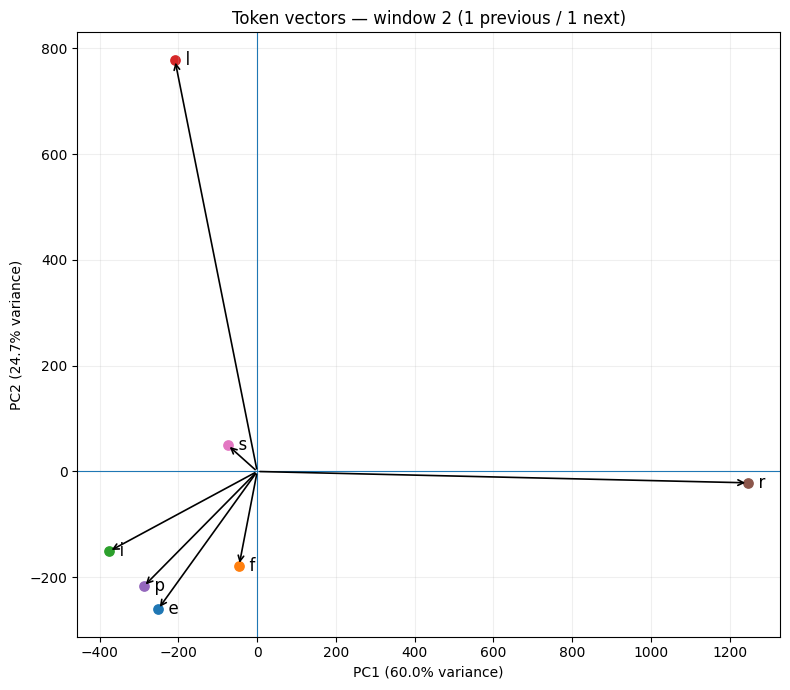


Window size: 4
Explained variance by PC1 + PC2: 91.6%


,PC1,PC2
e,-136.686643,-196.849286
f,-59.126926,-232.095453
i,-779.366992,-135.933172
l,7.872388,903.870213
p,-609.517812,-271.767436
r,1694.164226,-180.635881
s,-117.338241,113.411014


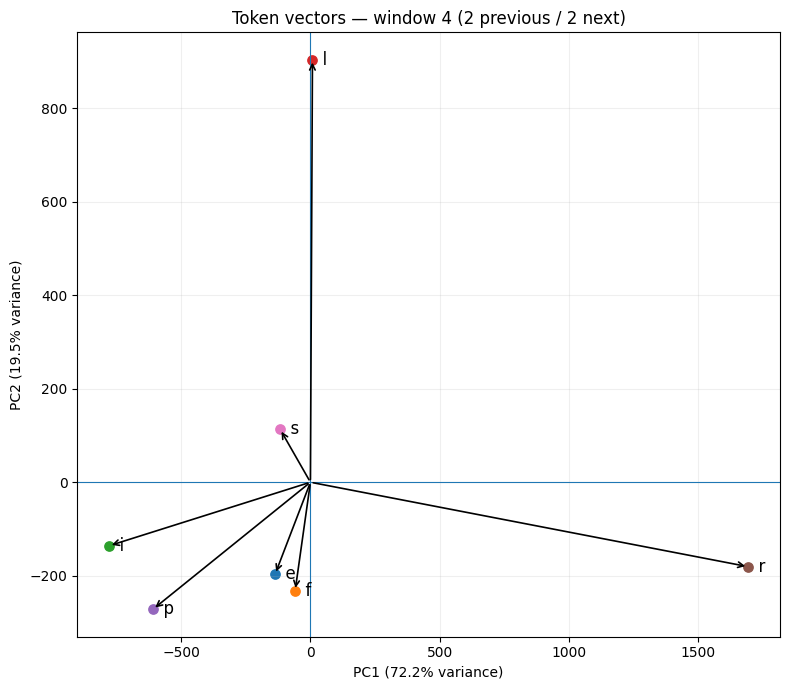


Window size: 6
Explained variance by PC1 + PC2: 93.1%


,PC1,PC2
e,-17.601393,-202.758424
f,-96.857955,-138.718367
i,-1028.663199,-112.267197
l,24.778739,904.279743
p,-816.335127,-257.602573
r,1977.217997,-184.870788
s,-42.539062,-8.062395


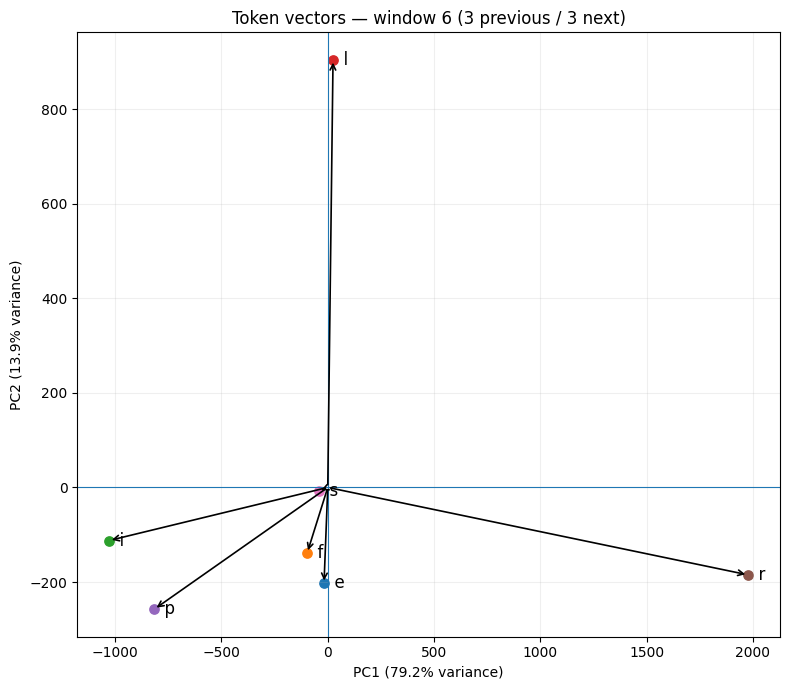

In [9]:
projections = {}
for window_size, matrix in cooccurrence_matrices.items():
    projected, pca = project_with_pca(matrix)
    projections[window_size] = projected
    print(f"\nWindow size: {window_size}")
    print(f"Explained variance by PC1 + PC2: {pca.explained_variance_ratio_.sum()*100:.1f}%")
    display(projected)
    plot_token_vectors(projected, window_size, pca)


## Interpretation

- Window 2: one token before and one after.
- Window 4: two before and two after.
- Window 6: three before and three after.

Changing the window changes the vectors themselves because it changes what counts as context. The rows of the co-occurrence matrix are already vector representations of tokens. PCA is only a visualization step.

This illustrates the distributional idea: **a token can be represented by the contexts in which it occurs.**

## Cosine similarity between token vectors

Each row of a co-occurrence matrix is a vector representing a token. We can compare two tokens by computing the cosine similarity between their vectors.

A value close to `1` means that the tokens have similar co-occurrence profiles; a value close to `0` means that their profiles point in very different directions. The computation is repeated independently for window sizes `2`, `4`, and `6`.


In [10]:
import numpy as np
from itertools import combinations

def cosine_similarity(v1, v2):
    norm1 = np.linalg.norm(v1)
    norm2 = np.linalg.norm(v2)
    if norm1 == 0 or norm2 == 0:
        return 0.0
    return float(np.dot(v1, v2) / (norm1 * norm2))


In [11]:
# Compute pairwise cosine similarities for each window size.
similarity_tables = {}

for window_size, matrix in cooccurrence_matrices.items():
    tokens = matrix.index.tolist()
    rows = []
    for token1, token2 in combinations(tokens, 2):
        v1 = matrix.loc[token1].to_numpy(dtype=float)
        v2 = matrix.loc[token2].to_numpy(dtype=float)
        rows.append({
            "token_1": token1,
            "token_2": token2,
            "cosine_similarity": cosine_similarity(v1, v2),
        })
    similarity_df = pd.DataFrame(rows).sort_values(
        "cosine_similarity", ascending=False).reset_index(drop=True)
    similarity_tables[window_size] = similarity_df
    print(f"Window size {window_size}")
    display(similarity_df)


Window size 2


,token_1,token_2,cosine_similarity
0,f,p,0.999716
1,i,l,0.935761
2,l,s,0.768466
3,r,s,0.767412
4,i,s,0.686494
5,f,r,0.545203
6,p,r,0.533336
7,f,s,0.486409
8,p,s,0.479169
9,e,s,0.317492


Window size 4


,token_1,token_2,cosine_similarity
0,f,p,0.999670
1,f,r,0.854672
2,p,r,0.848131
3,e,r,0.845229
4,l,s,0.822664
5,i,l,0.818481
6,r,s,0.808251
7,f,s,0.790596
8,p,s,0.789244
9,i,s,0.692942


Window size 6


,token_1,token_2,cosine_similarity
0,f,p,0.998498
1,f,r,0.930113
2,e,s,0.924977
3,p,r,0.919854
4,e,r,0.912071
5,r,s,0.888317
6,f,s,0.826459
7,p,s,0.810967
8,l,s,0.793794
9,i,l,0.787103


### Compare one pair across context windows

Change `TOKEN_1` and `TOKEN_2` to explore how their similarity changes when the context window becomes larger.


In [12]:
TOKEN_1 = "r"
TOKEN_2 = "l"

pair_results = []
for window_size, similarity_df in similarity_tables.items():
    mask = (((similarity_df["token_1"] == TOKEN_1) & (similarity_df["token_2"] == TOKEN_2)) |
            ((similarity_df["token_1"] == TOKEN_2) & (similarity_df["token_2"] == TOKEN_1)))
    match = similarity_df.loc[mask]
    if len(match):
        pair_results.append({"window_size": window_size, "token_1": TOKEN_1, "token_2": TOKEN_2,
                             "cosine_similarity": match.iloc[0]["cosine_similarity"]})

pd.DataFrame(pair_results)


,window_size,token_1,token_2,cosine_similarity
0,2,r,l,0.300089
1,4,r,l,0.596509
2,6,r,l,0.697038


## Save cosine similarities


In [13]:
for window_size, similarity_df in similarity_tables.items():
    filename = f"{window_size}-cosine-similarities.csv"
    similarity_df.to_csv(filename, index=False)
    print(f"Saved: {filename}")


Saved: 2-cosine-similarities.csv
Saved: 4-cosine-similarities.csv
Saved: 6-cosine-similarities.csv
